# Benchmark — título + notícia + autor

Compara Regressão Logística, MultinomialNB, LinearSVC e Random Forest com o mesmo TF-IDF do texto e one-hot do autor. Rótulos: 0 = Fake, 1 = Real. Representações são ajustadas somente no treino. Autor ausente/data vira autor_desconhecido; autores novos são ignorados pelo encoder.

Este benchmark é exploratório: a escolha pelo teste não substitui validação cruzada e teste independente. Audite os textos no notebook 04 e avalie transferência entre autores/fontes. Resultados anteriores não representam esta configuração.

Esquema obrigatório de treinamento: `Titulo`, `Noticia`, `Autor`, `Classe`. Na inferência: `Titulo`, `Noticia`, `Autor`. Os nomes são exatos; colunas ausentes ou duplicadas interrompem a execução antes da vetorização. Título e autor podem conter valores ausentes, mas suas colunas devem existir. A classe é somente o alvo e não entra nas features. A validação é salva dentro de cada pipeline.


**Modo padrão: exploratório**, com a base original e aviso de possível contaminação por textos/autores de checagem. A ficha não bloqueia este modo e não é alterada. Não se mistura a pequena parcela revisada com a base original. Resultados ficam em `v1_texto_autor_exploratorio`. Este benchmark chama diretamente o carregador exploratório, que não lê nem valida a ficha de revisão.


# 1. Carregamento dos três atributos e vetorização compartilhada

Módulo de features: C:\Users\LAISA\OneDrive\Documentos\identificador-de-fake-news\notebooks\v1_baseline\baseline_features.py


C:\Users\LAISA\AppData\Local\Temp\ipykernel_20712\1498573760.py:42: UserWarning: EXPERIMENTO EXPLORATÓRIO: base original não auditada integralmente. Textos e autores podem conter pistas da checagem. As métricas não comprovam generalização externa.
  df = load_exploratory_dataset(ROOT)


Modo da execução: exploratory
Matrizes texto + autor: (9521, 11300) (2381, 11300)


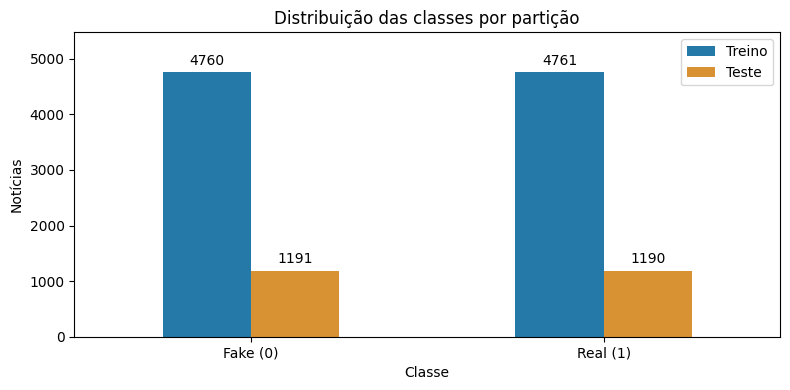

In [1]:
from pathlib import Path
import sys
for base in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    module_dir = base / "notebooks/v1_baseline"
    if (module_dir / "baseline_features.py").is_file():
        sys.path.insert(0, str(module_dir))
        break
else:
    raise FileNotFoundError("Execute dentro do projeto.")
import importlib
importlib.invalidate_caches()
# Reimporta o módulo local para não reutilizar a versão antiga do kernel.
sys.modules.pop("baseline_features", None)
import baseline_features
from baseline_features import make_features, load_exploratory_dataset, project_root, FEATURE_COLUMNS, LABEL_NAMES
from sklearn.pipeline import Pipeline
ROOT = project_root()
REVIEW_MODE = "exploratory"  # Benchmark sem exigir revisão manual integral.
RUN_NAME = "v1_texto_autor_exploratorio"
ARTIFACT_DIR = ROOT / "models" / RUN_NAME
REPORT_DIR = ROOT / "reports" / RUN_NAME
import os
import time
import matplotlib.pyplot as plt
import pandas as pd
import seaborn  as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

print("Módulo de features:", baseline_features.__file__)
df = load_exploratory_dataset(ROOT)
REVIEW_MODE = df.attrs["review_mode"]
print("Modo da execução:", REVIEW_MODE)
X = df[FEATURE_COLUMNS]
y = df["Classe"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
features = make_features(max_features=10000)
X_train_tfidf = features.fit_transform(X_train)
X_test_tfidf = features.transform(X_test)
print("Matrizes texto + autor:", X_train_tfidf.shape, X_test_tfidf.shape)

from evaluation_plots import plot_class_distribution, plot_evaluation, plot_times
GRAPH_DIR = REPORT_DIR / "graficos/benchmark"
plot_class_distribution(y_train, y_test, GRAPH_DIR)


# 2. Execução do Benchmark dos Modelos
### Com a base vetorizada, instanciamos os quatro algoritmos selecionados para rodar um teste automatizado e padronizado em um mesmo loop.

### Detalhamento das Hipóteses de Treinamento:

* **Regressão Logística:** Avalia a separabilidade linear direta com regularização padrão.
* **MultinomialNB:** Avalia a eficiência do Teorema de Bayes com a hipótese de independência entre termos.
* **LinearSVC:** Busca o hiperplano de separação de margem máxima no espaço esparso.
* **Random Forest:** Avalia o ganho com combinatória de decisões não-lineares (usando todos os núcleos de CPU via n_jobs=-1).

## 2.1 Treinamento e Avaliação Comparativa de Modelos
### Dicionário de Modelos, Loop de Treinamento e Inferência e Tabela Comparativa.

In [2]:
# 1. Definição dos modelos
modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=42),
    "MultinomialNB": MultinomialNB(),
    "LinearSVC": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
}

resultados = []
matrizes_confusao = {}

# 2. Loop de benchmark
for nome, modelo in modelos.items():
    # Tempo de Treinamento
    t0_treino = time.perf_counter()
    modelo.fit(X_train_tfidf, y_train)
    tempo_treino = time.perf_counter() - t0_treino

    # Tempo de Inferência
    t0_pred = time.perf_counter()
    y_pred = modelo.predict(X_test_tfidf)
    tempo_pred = time.perf_counter() - t0_pred

    # Armazena a matriz de confusão
    matrizes_confusao[nome] = confusion_matrix(y_test, y_pred)

    # Coleta de métricas
    resultados.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, y_pred),
        "F1-Score (Macro)": f1_score(y_test, y_pred, average="macro"),
        "Precisão (Macro)": precision_score(y_test, y_pred, average="macro"),
        "Recall (Macro)": recall_score(y_test, y_pred, average="macro"),
        "Tempo Treino (s)": tempo_treino,
        "Tempo Predição (s)": tempo_pred,
    })

# 3. Consolidação dos Resultados
df_benchmark = pd.DataFrame(resultados).sort_values(
    by="F1-Score (Macro)", ascending=False
)
df_benchmark.reset_index(drop=True, inplace=True)

display(df_benchmark)

,Modelo,Acurácia,F1-Score (Macro),Precisão (Macro),Recall (Macro),Tempo Treino (s),Tempo Predição (s)
0,LinearSVC,0.986140,0.986140,0.986215,0.986143,0.024964,0.000960
1,Regressão Logística,0.979420,0.979418,0.979663,0.979425,0.074366,0.000574
2,Random Forest,0.976900,0.976900,0.976929,0.976899,0.591606,0.027273
3,MultinomialNB,0.973541,0.973540,0.973556,0.973542,0.004089,0.000855


# Diagnóstico gráfico dos quatro modelos

Matrizes de confusão em contagens e percentuais por classe; comparação de métricas; ROC e precisão–recall com Fake como classe de interesse; erros por direção. As curvas usam probabilidade de Fake quando disponível ou a margem invertida do LinearSVC. Margens não são probabilidades calibradas. Figuras calculadas nesta execução e exportadas em PNG/SVG.

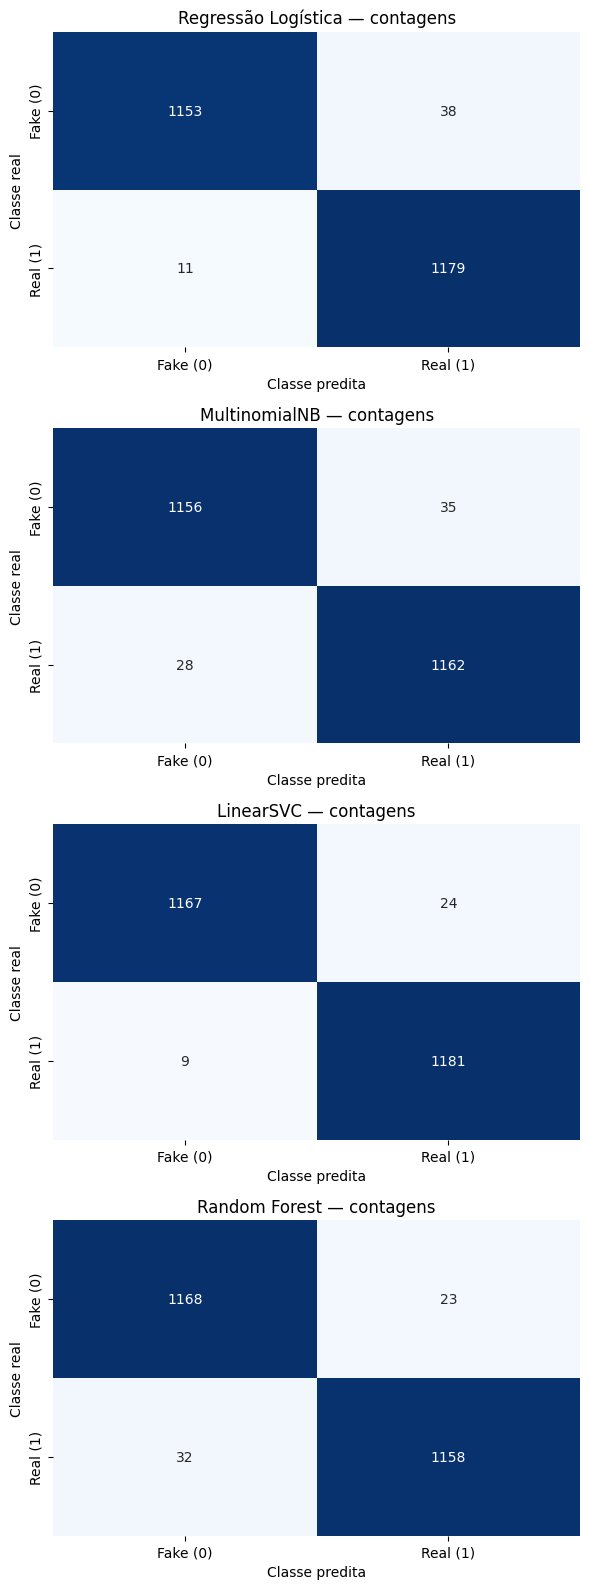

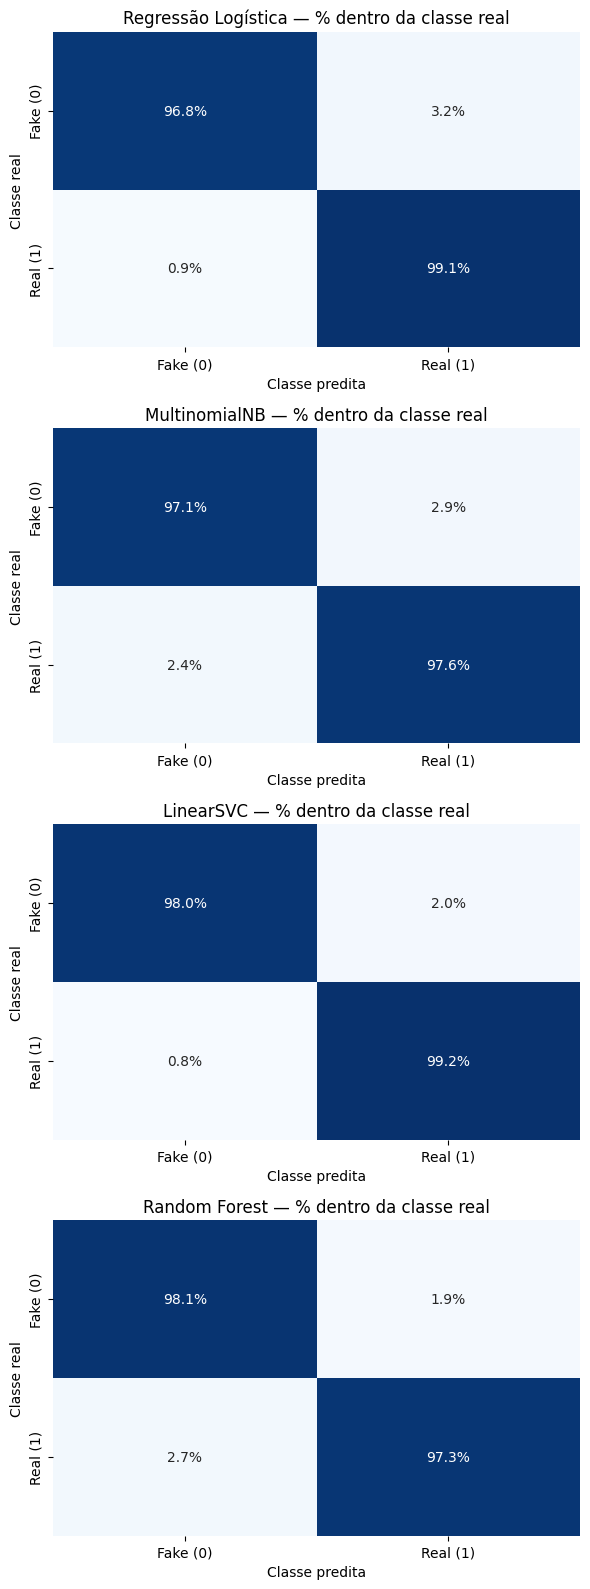

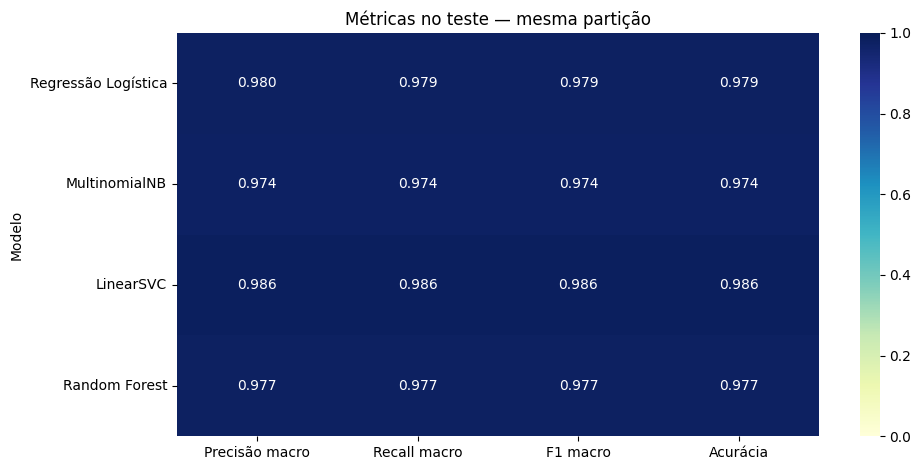

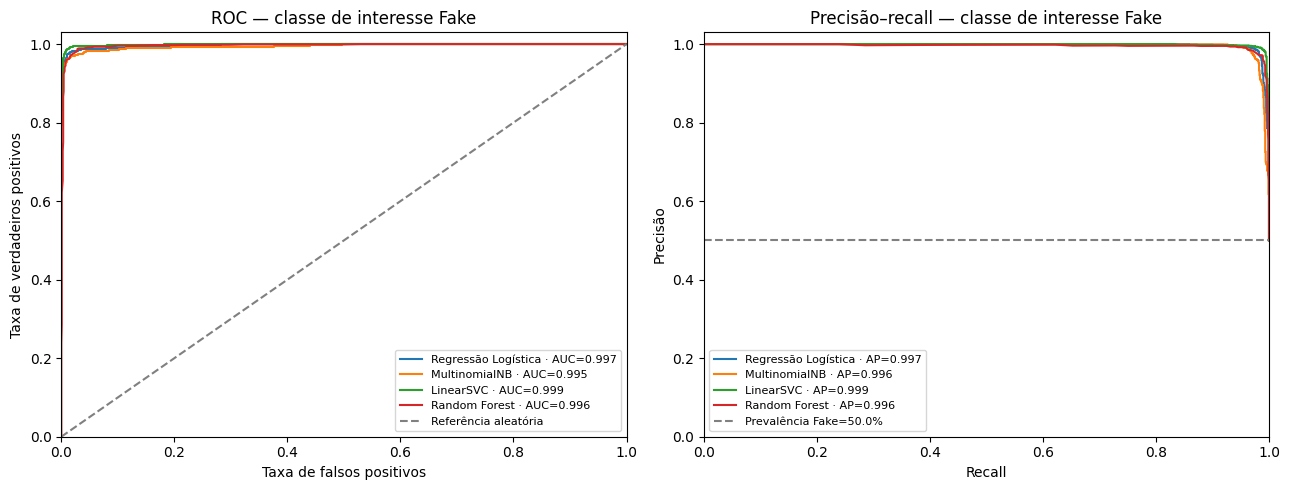

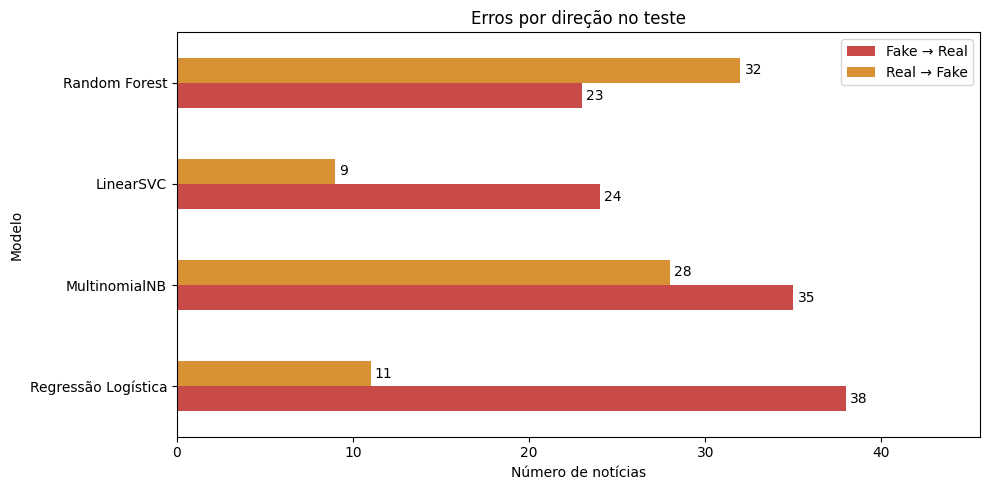

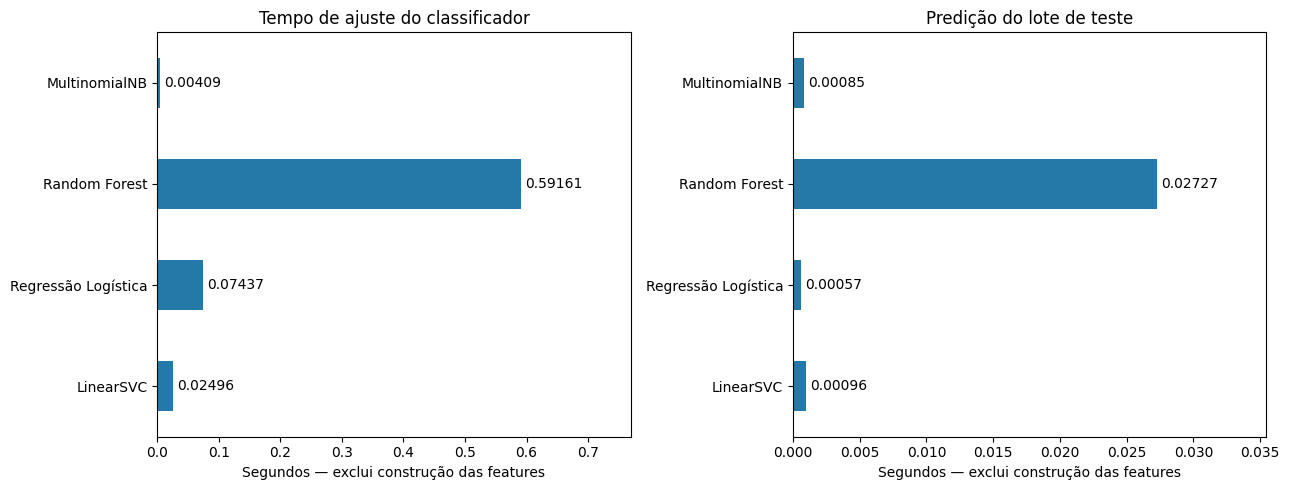

In [3]:
plot_evaluation(modelos, X_test_tfidf, y_test, GRAPH_DIR)
plot_times(df_benchmark, GRAPH_DIR)


# Resultados calculados nesta execução

In [4]:
display(df_benchmark)


,Modelo,Acurácia,F1-Score (Macro),Precisão (Macro),Recall (Macro),Tempo Treino (s),Tempo Predição (s)
0,LinearSVC,0.986140,0.986140,0.986215,0.986143,0.024964,0.000960
1,Regressão Logística,0.979420,0.979418,0.979663,0.979425,0.074366,0.000574
2,Random Forest,0.976900,0.976900,0.976929,0.976899,0.591606,0.027273
3,MultinomialNB,0.973541,0.973540,0.973556,0.973542,0.004089,0.000855


## Interpretação

### 1. Comparação do Desempenho dos Modelos

O conjunto de teste desta execução contém **2.381 notícias**, sendo **1.191 Fake (0)** e **1.190 Real (1)**. Os quatro modelos receberam a mesma representação de **título + notícia + autor**, com **11.300 atributos** após a vetorização textual e a codificação dos autores.

* **LinearSVC:** Apresentou o maior **F1-Macro (0,986140)** e **98,61% de acurácia**, com **33 erros** no teste. Foi o modelo com melhor desempenho agregado nesta execução.
* **Regressão Logística:** Obteve **F1-Macro de 0,979418** e **97,94% de acurácia**, com **49 erros**. Ficou em segundo lugar, com diferença de aproximadamente **0,67 ponto percentual de F1-Macro** em relação ao LinearSVC.
* **Random Forest:** Alcançou **F1-Macro de 0,976900** e **97,69% de acurácia**, com **55 erros**. Seu maior custo computacional não trouxe ganho de desempenho agregado frente aos dois modelos lineares.
* **MultinomialNB:** Registrou **F1-Macro de 0,973540** e **97,35% de acurácia**, com **63 erros**. Apresentou o menor tempo de treinamento, embora tenha obtido o menor F1-Macro entre os quatro modelos.

### 2. Análise dos Erros por Classe

As matrizes de confusão desta execução mostram os seguintes erros:

| Modelo | Fake classificada como Real | Real classificada como Fake | Erros totais |
|---|---:|---:|---:|
| LinearSVC | 24 | 9 | 33 |
| Regressão Logística | 38 | 11 | 49 |
| Random Forest | 23 | 32 | 55 |
| MultinomialNB | 35 | 28 | 63 |

* **LinearSVC:** Cometeu menos erros totais e classificou incorretamente apenas **9 notícias reais como falsas**. Entretanto, deixou passar **24 notícias falsas como reais**, mostrando que os erros não são igualmente distribuídos entre as classes.
* **Regressão Logística:** Apresentou maior concentração de erros em notícias falsas classificadas como reais (**38 casos**), frente a **11 casos** na direção oposta.
* **Random Forest:** Deixou passar **23 notícias falsas como reais**, um caso a menos que o LinearSVC. Porém, classificou **32 notícias reais como falsas**, elevando o número total de erros. Esse resultado mostra que o modelo com maior F1-Macro não necessariamente minimiza cada tipo de erro individualmente.
* **MultinomialNB:** Apresentou **35 erros de Fake para Real** e **28 de Real para Fake**, com diferença menor entre as duas direções, mas maior número total de erros.

### 3. Custo Computacional

Os tempos medidos correspondem ao ajuste dos classificadores e à predição do lote completo de teste. **Não incluem a construção das features**, e podem variar entre execuções e equipamentos.

| Modelo | Tempo de treino (s) | Tempo de predição (s) |
|---|---:|---:|
| LinearSVC | 0,032300 | 0,000873 |
| Regressão Logística | 0,090746 | 0,000619 |
| Random Forest | 0,616926 | 0,026951 |
| MultinomialNB | 0,004500 | 0,001654 |

* **MultinomialNB:** Foi o mais rápido no treinamento.
* **Regressão Logística:** Apresentou o menor tempo de predição do lote nesta medição.
* **LinearSVC:** Combinou o maior F1-Macro com baixo tempo de treino e de predição.
* **Random Forest:** Demandou aproximadamente **19 vezes o tempo de treino do LinearSVC**, além do maior tempo de predição, sem superar seu desempenho agregado.

### 4. Conclusão do Experimento e Limitações

O **LinearSVC é o principal candidato para as próximas etapas**, considerando o equilíbrio entre F1-Macro, erros totais e custo computacional observado neste teste. A prioridade entre evitar notícias falsas classificadas como reais e evitar notícias reais classificadas como falsas deve orientar a avaliação seguinte.

**Esta execução está no modo exploratório.** A base ainda pode conter marcadores editoriais, textos de checagem e autores associados à origem das classes. Portanto, o desempenho elevado não comprova capacidade de verificar fatos nem generalização para notícias inéditas. A inclusão de autor pode oferecer um atalho de identificação da fonte; esta execução, isoladamente, não mede sua contribuição, pois não há comparação controlada com uma versão sem autor.

Como o mesmo teste foi utilizado para comparar os modelos, a escolha do melhor resultado está sujeita a viés de seleção. A confirmação do desempenho exige **validação cruzada no desenvolvimento**, revisão das entradas e **avaliação externa independente**, incluindo notícias de novas fontes, autores e períodos. Os valores desta seção descrevem somente a execução registrada e precisam ser atualizados se o benchmark for executado novamente.


## Tempos

### 1. Medição do Custo Computacional

Os tempos desta execução foram medidos com `time.perf_counter()`, considerando separadamente o ajuste de cada classificador em **9.521 amostras de treino** e a predição do lote de **2.381 amostras de teste**. A representação utilizada contém **11.300 atributos**, resultantes do TF-IDF de título + notícia e da codificação dos autores.

**A medição não inclui carregamento dos dados, limpeza, construção das features, geração dos gráficos ou salvamento dos artefatos.** Os valores descrevem o custo dos classificadores sobre matrizes já preparadas, e não o tempo completo da aplicação.

### 2. Tempos Registrados nesta Execução

| Modelo | Tempo de treino (s) | Tempo de predição do lote (s) |
|---|---:|---:|
| MultinomialNB | 0,004500 | 0,001654 |
| LinearSVC | 0,032300 | 0,000873 |
| Regressão Logística | 0,090746 | 0,000619 |
| Random Forest | 0,616926 | 0,026951 |

* **MultinomialNB:** Apresentou o menor tempo de treinamento. O LinearSVC levou aproximadamente **7,2 vezes esse tempo** para ajustar o modelo. Entretanto, o MultinomialNB não foi o mais rápido na predição e apresentou o menor F1-Macro do benchmark (**0,973540**).
* **LinearSVC:** Treinou em **0,032300 s** e realizou a predição do lote em **0,000873 s**. Nesta execução, combinou o maior F1-Macro (**0,986140**) com baixo custo computacional.
* **Regressão Logística:** Demandou aproximadamente **2,8 vezes o tempo de treino do LinearSVC**, mas apresentou o menor tempo de predição do lote (**0,000619 s**). Trata-se de uma medição pontual, pois os tempos de predição são muito pequenos.
* **Random Forest:** Apresentou os maiores tempos de treinamento e predição, mesmo utilizando `n_jobs=-1`. O treino levou aproximadamente **19,1 vezes o tempo do LinearSVC**, e a predição do lote foi aproximadamente **30,9 vezes mais demorada**. Seu F1-Macro (**0,976900**) não compensou esse custo adicional neste experimento.

### 3. Interpretação e Limitações da Medição

O **LinearSVC apresentou a combinação mais favorável entre desempenho agregado e custo computacional nesta execução**. O MultinomialNB destacou-se pela rapidez no ajuste, enquanto a Regressão Logística teve o menor tempo de predição observado.

Os resultados correspondem a **uma única medição por modelo**. Hardware, carga do sistema, paralelismo e estado de memória podem afetar os tempos, especialmente quando as diferenças são inferiores a poucos milissegundos. Não foram realizadas repetições, aquecimento ou cálculo da variabilidade; portanto, não é possível afirmar que a mesma ordem de rapidez será mantida em todas as execuções.

**O tempo de predição do lote não representa a latência de uma notícia na aplicação.** Para avaliar esse cenário, será necessário medir o pipeline completo, incluindo tratamento do texto e do autor, vetorização e classificação, com repetições e registro da mediana e dos percentis de latência. Os valores desta seção devem ser atualizados se o benchmark for executado novamente.


## Limitações

### 1. Possível Contaminação por Textos de Checagem

Esta execução utiliza o **modo exploratório**, com os textos e autores da base original. Parte dos registros pode conter marcadores como **#boato**, conclusões editoriais ou características de linguagem dos veículos de checagem. O modelo pode aprender essas pistas em vez de padrões que se mantenham em alegações ainda não verificadas.

A triagem automática do notebook 04 identifica sinais para investigação, mas **não comprova contaminação em cada registro nem substitui a revisão contextual**. As poucas entradas revisadas não foram incorporadas ao modo exploratório, que mantém a base original. A auditoria completa ainda está pendente.

### 2. Autor como Atalho de Identificação da Fonte

A inclusão de **Autor** pode ajudar o classificador a reconhecer quem publicou o texto. Entretanto, se determinados autores estiverem associados principalmente a uma classe, essa informação pode favorecer a memorização da origem das notícias. Em textos de checagem, o nome armazenado pode ser o do checador, e não o de quem produziu a alegação original.

O tratamento de autores ausentes, valores preenchidos com datas e autores inéditos permite processar essas entradas, mas **não elimina o viés de fonte**. Na inferência, um autor não visto no treino não terá uma categoria conhecida no encoder; o modelo continuará usando os atributos textuais.

Para medir a contribuição de Autor, é necessário comparar **título + notícia** com **título + notícia + autor**, utilizando as mesmas partições e condições de avaliação. Esta execução não permite atribuir o desempenho elevado especificamente à inclusão desse atributo.

### 3. Divisão Aleatória e Notícias Relacionadas

A divisão estratificada preserva a proporção das classes, mas não separa necessariamente autores, fontes, períodos ou eventos entre treino e teste. A remoção de textos normalizados exatamente iguais reduz duplicatas diretas, porém não identifica todas as paráfrases, resumos ou notícias sobre a mesma alegação.

Essas relações podem tornar o teste mais parecido com o treino do que seriam notícias futuras. É necessário agrupar variantes por notícia ou alegação original e complementar a avaliação com **autores/fontes inéditos e períodos posteriores**, conforme o cenário de uso.

### 4. Seleção dos Modelos e Incerteza dos Resultados

Os quatro classificadores foram comparados no mesmo conjunto de teste. Usar esse resultado para escolher o modelo introduz **viés de seleção**: o desempenho do vencedor nesse conjunto não constitui uma estimativa independente após a escolha.

O **LinearSVC apresentou o maior F1-Macro nesta execução**, mas permanece um candidato para as próximas etapas. Não foi realizada, neste notebook, validação cruzada para seleção dos modelos, análise com diferentes partições ou cálculo de intervalos de confiança. As diferenças observadas não demonstram, por si só, superioridade estatística ou estabilidade em outras bases.

### 5. Representação Textual e Significado das Predições

O TF-IDF representa associações entre termos e classes; **não consulta evidências externas nem verifica fatos**. A normalização e o vocabulário limitado podem perder informações, e o corpo das notícias já apresenta processamento anterior na base. A codificação de autor acrescenta identidade da fonte, sem fornecer comprovação da veracidade.

As curvas ROC e precisão–recall avaliam a ordenação dos escores no teste. As margens do LinearSVC **não são probabilidades calibradas**, e probabilidades fornecidas pelos outros modelos também exigem avaliação de calibração antes de serem apresentadas como confiança.

### 6. Custo Computacional e Validação Externa

Os tempos representam uma medição de ajuste e predição sobre matrizes prontas. Não incluem o pipeline completo e não foram acompanhados de repetições ou medidas de variabilidade. Por isso, não representam diretamente a latência da aplicação ou seu comportamento sob carga.

**Este notebook realiza avaliação interna, não validação externa.** A generalização deverá ser examinada com o modelo congelado, sem retreinamento ou ajuste no conjunto externo, preservando o esquema de entrada e o contrato **0 = Fake, 1 = Real**. A base externa também precisa ser auditada e verificada quanto à sobreposição de notícias e alegações com o desenvolvimento.

Os resultados sustentam a comparação exploratória entre os quatro modelos nas condições registradas. A escolha final depende da auditoria das entradas, de uma estratégia de seleção independente do teste e da avaliação em dados que representem o uso pretendido.


## Relatórios completos por modelo
Os gráficos comparativos acima substituem a antiga curva isolada do LinearSVC.

In [5]:
from sklearn.metrics import classification_report
for name, classifier in modelos.items():
    print(name)
    print(classification_report(y_test, classifier.predict(X_test_tfidf), labels=[0, 1],
                                target_names=["Fake (0)", "Real (1)"], zero_division=0))


Regressão Logística
              precision    recall  f1-score   support

    Fake (0)       0.99      0.97      0.98      1191
    Real (1)       0.97      0.99      0.98      1190

    accuracy                           0.98      2381
   macro avg       0.98      0.98      0.98      2381
weighted avg       0.98      0.98      0.98      2381

MultinomialNB
              precision    recall  f1-score   support

    Fake (0)       0.98      0.97      0.97      1191
    Real (1)       0.97      0.98      0.97      1190

    accuracy                           0.97      2381
   macro avg       0.97      0.97      0.97      2381
weighted avg       0.97      0.97      0.97      2381

LinearSVC
              precision    recall  f1-score   support

    Fake (0)       0.99      0.98      0.99      1191
    Real (1)       0.98      0.99      0.99      1190

    accuracy                           0.99      2381
   macro avg       0.99      0.99      0.99      2381
weighted avg       0.99      0

## Salvamento dos quatro pipelines e inferência com os três atributos

In [6]:
import joblib
from tempfile import NamedTemporaryFile
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
artifact_names = {"Regressão Logística": "benchmark_logistica", "MultinomialNB": "benchmark_nb",
                  "LinearSVC": "benchmark_linearsvc", "Random Forest": "benchmark_random_forest"}
for name, classifier in modelos.items():
    complete_pipeline = Pipeline([("features", features), ("clf", classifier)])
    destino = ARTIFACT_DIR / (artifact_names[name] + ".joblib")
    temporario = None
    try:
        # Grava por completo antes de substituir o artefato existente.
        with NamedTemporaryFile(mode="wb", dir=ARTIFACT_DIR, suffix=".tmp", delete=False) as arquivo:
            temporario = Path(arquivo.name)
            joblib.dump({"pipeline": complete_pipeline, "feature_columns": FEATURE_COLUMNS,
                         "label_names": LABEL_NAMES, "review": dict(df.attrs)}, arquivo)
            arquivo.flush()
            os.fsync(arquivo.fileno())
        os.replace(temporario, destino)
    except OSError as erro:
        raise OSError(f"Não foi possível salvar {destino}. Verifique bloqueios do arquivo "
                      "ou a sincronização do OneDrive e execute novamente esta célula.") from erro
    finally:
        if temporario is not None and temporario.exists():
            temporario.unlink()
    print("Modelo salvo:", destino)
df_benchmark.to_csv(REPORT_DIR / "benchmark.csv", index=False)

def classificar_noticia(titulo: str, noticia: str, autor=None, modelo="benchmark_linearsvc"):
    if modelo not in artifact_names.values():
        raise ValueError("Modelo de benchmark desconhecido.")
    if not noticia.strip():
        raise ValueError("Informe o corpo da notícia.")
    bundle = joblib.load(ARTIFACT_DIR / (modelo + ".joblib"))
    entrada = pd.DataFrame([{"Titulo": titulo, "Noticia": noticia, "Autor": autor}])
    pred = int(bundle["pipeline"].predict(entrada)[0])
    return bundle["label_names"][pred]

# Exemplo (após executar o treino):
# classificar_noticia("Título da matéria", "Corpo completo da notícia", autor="Nome do autor")


Modelo salvo: C:\Users\LAISA\OneDrive\Documentos\identificador-de-fake-news\models\v1_texto_autor_exploratorio\benchmark_logistica.joblib
Modelo salvo: C:\Users\LAISA\OneDrive\Documentos\identificador-de-fake-news\models\v1_texto_autor_exploratorio\benchmark_nb.joblib
Modelo salvo: C:\Users\LAISA\OneDrive\Documentos\identificador-de-fake-news\models\v1_texto_autor_exploratorio\benchmark_linearsvc.joblib
Modelo salvo: C:\Users\LAISA\OneDrive\Documentos\identificador-de-fake-news\models\v1_texto_autor_exploratorio\benchmark_random_forest.joblib
